## 1. Instalasi & Import Library

In [ ]:
# Install kagglehub jika belum tersedia
!pip install kagglehub -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Model saving
import joblib
import os

# Styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!



##  2. Load Dataset dari Kaggle

In [ ]:
# Download latest version
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-habits-vs-academic-performance' dataset.
Path to dataset files: /kaggle/input/student-habits-vs-academic-performance


In [ ]:
# Cari file CSV di dalam folder
import glob
csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
print('File CSV ditemukan:', csv_files)

df_raw = pd.read_csv(csv_files[0])
print(f'\n✅ Dataset berhasil dimuat: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
df_raw.head()

File CSV ditemukan: ['/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv']

✅ Dataset berhasil dimuat: 1000 baris, 16 kolom


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



##  3. Data Understanding

In [ ]:
# Informasi umum dataset
print('=' * 60)
print('INFORMASI UMUM DATASET')
print('=' * 60)
print(f'Jumlah data    : {df_raw.shape[0]} baris')
print(f'Jumlah fitur   : {df_raw.shape[1]} kolom')
print()
df_raw.info()

INFORMASI UMUM DATASET
Jumlah data    : 1000 baris
Jumlah fitur   : 16 kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       

In [ ]:
# Statistik deskriptif
print('STATISTIK DESKRIPTIF')
df_raw.describe().round(2)

STATISTIK DESKRIPTIF


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


In [ ]:
# Cek missing values
print('MISSING VALUES')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print('✅ Tidak ada missing values!')
else:
    print(missing_df)

MISSING VALUES
                          Missing Count  Missing %
parental_education_level             91        9.1


In [ ]:
# Cek duplikat
print(f'Jumlah duplikat: {df_raw.duplicated().sum()}')

# Identifikasi kolom numerik dan kategorikal
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(include=['object']).columns.tolist()
print(f'\nKolom numerik ({len(num_cols)}): {num_cols}')
print(f'Kolom kategorikal ({len(cat_cols)}): {cat_cols}')

Jumlah duplikat: 0

Kolom numerik (9): ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Kolom kategorikal (7): ['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


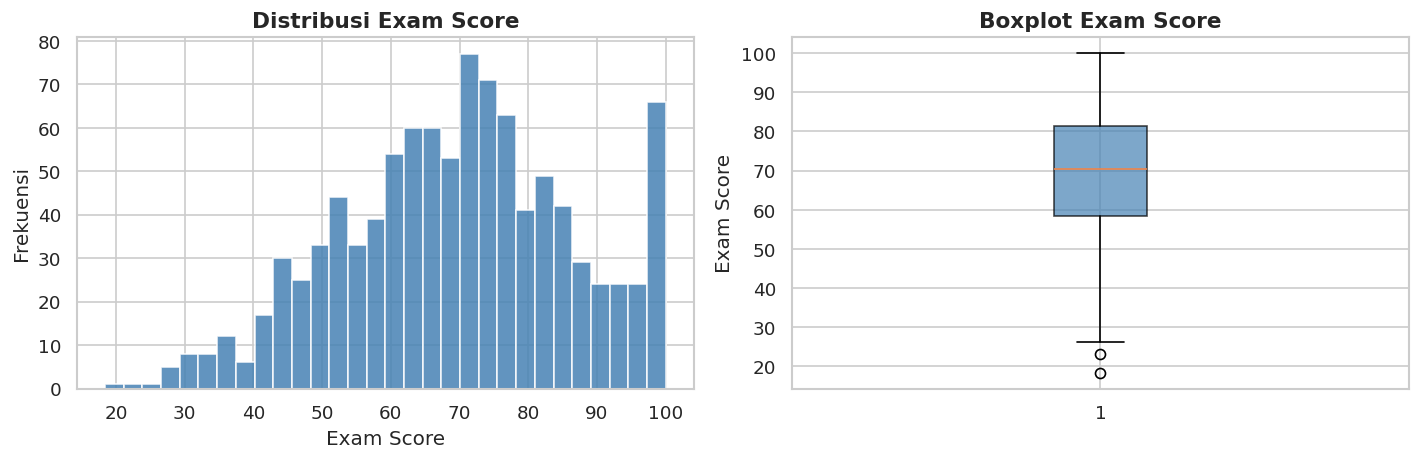


Skor rata-rata : 69.60
Std deviasi    : 16.89
Min - Max      : 18.4 - 100.0


In [ ]:
# Distribusi variabel target (exam_score)
target_col = 'exam_score'  # Sesuaikan jika nama kolom berbeda

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw[target_col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Exam Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df_raw[target_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot Exam Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.savefig('dist_exam_score.png', bbox_inches='tight')
plt.show()
print(f'\nSkor rata-rata : {df_raw[target_col].mean():.2f}')
print(f'Std deviasi    : {df_raw[target_col].std():.2f}')
print(f'Min - Max      : {df_raw[target_col].min()} - {df_raw[target_col].max()}')

In [ ]:
# Fitur utama yang relevan dengan tema
# Sesuaikan nama kolom dengan hasil df_raw.columns di atas
KEY_FEATURES = [
    'sleep_hours',          # jam tidur
    'study_hours_per_day',  # jam belajar
    'social_media_hours',   # jam sosmed
    'physical_activity_hours',  # jam olahraga
    'attendance_percentage',    # kehadiran
    'exam_score'            # target
]

# Cek apakah kolom ada (sesuaikan nama jika perlu)
available = [c for c in KEY_FEATURES if c in df_raw.columns]
print('Kolom tersedia:', available)
print('Semua kolom dataset:', df_raw.columns.tolist())

Kolom tersedia: ['sleep_hours', 'study_hours_per_day', 'social_media_hours', 'attendance_percentage', 'exam_score']
Semua kolom dataset: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


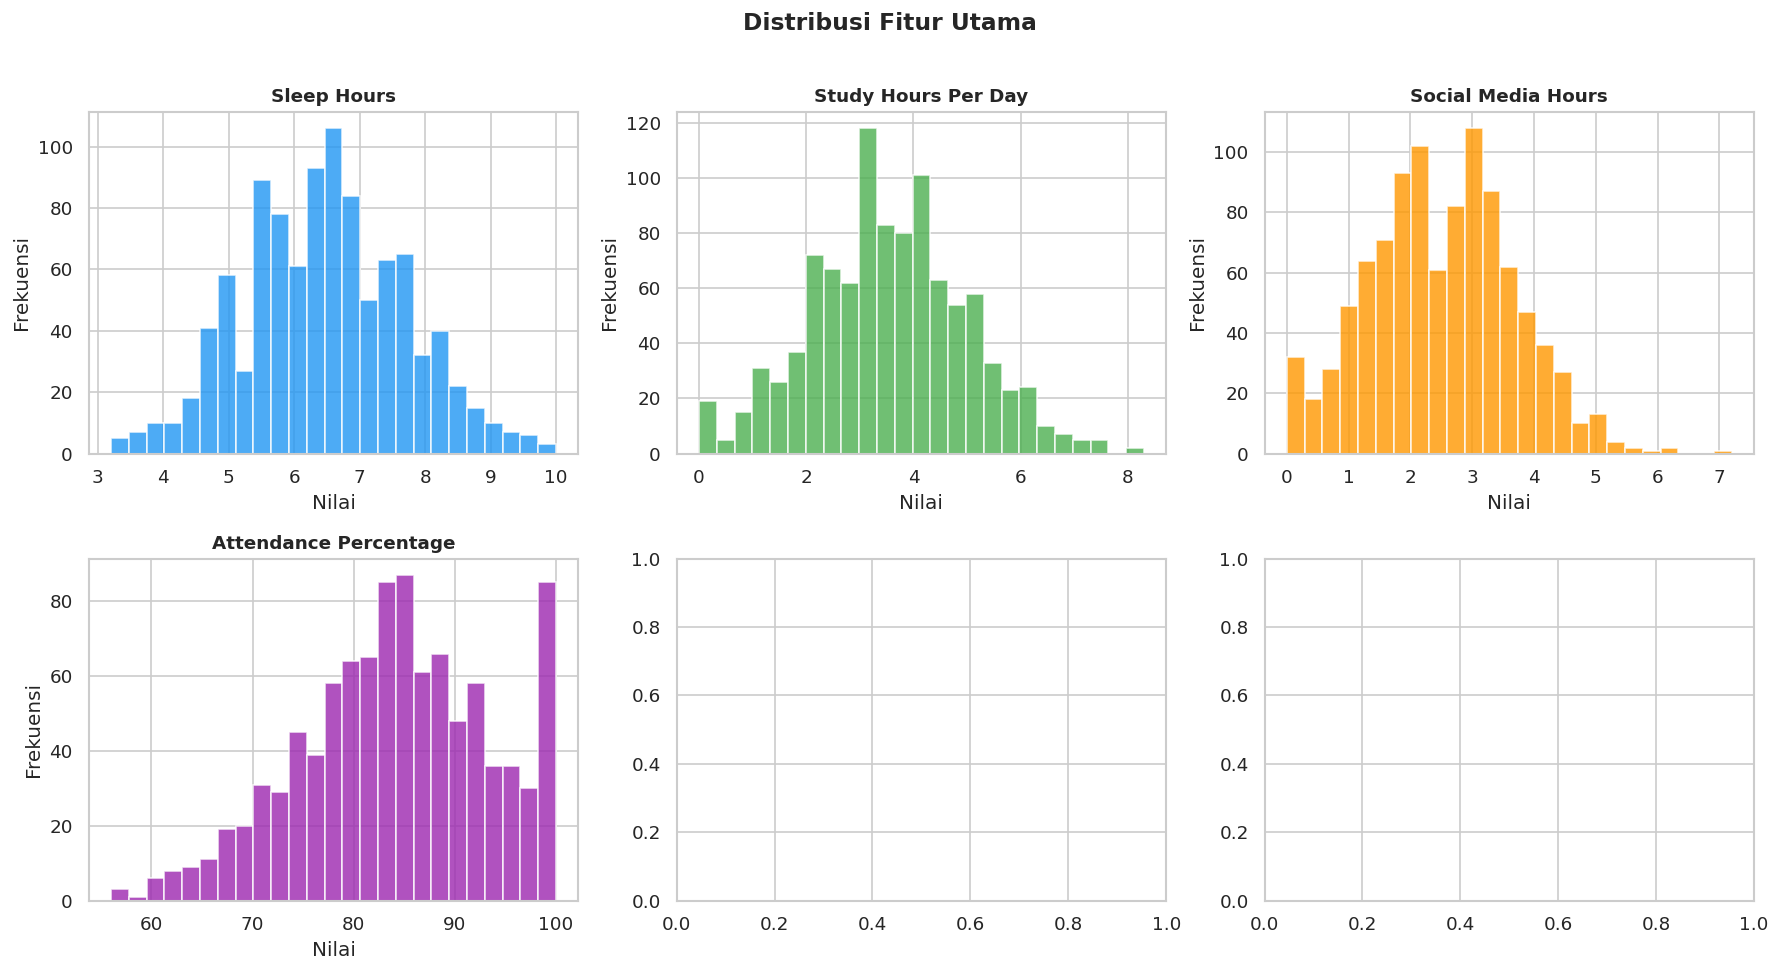

In [ ]:
# ⚠️ PENTING: Setelah cek kolom di atas, update KEY_FEATURES sesuai nama kolom asli
# Contoh jika nama berbeda:
# KEY_FEATURES = ['sleep_hours', 'study_hours_per_day', 'social_media_hours',
#                 'exercise_frequency', 'attendance_percentage', 'exam_score']

# Visualisasi distribusi fitur utama
feature_cols = [c for c in KEY_FEATURES if c != target_col and c in df_raw.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
for i, col in enumerate(feature_cols[:6]):
    axes[i].hist(df_raw[col], bins=25, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dist_fitur_utama.png', bbox_inches='tight')
plt.show()

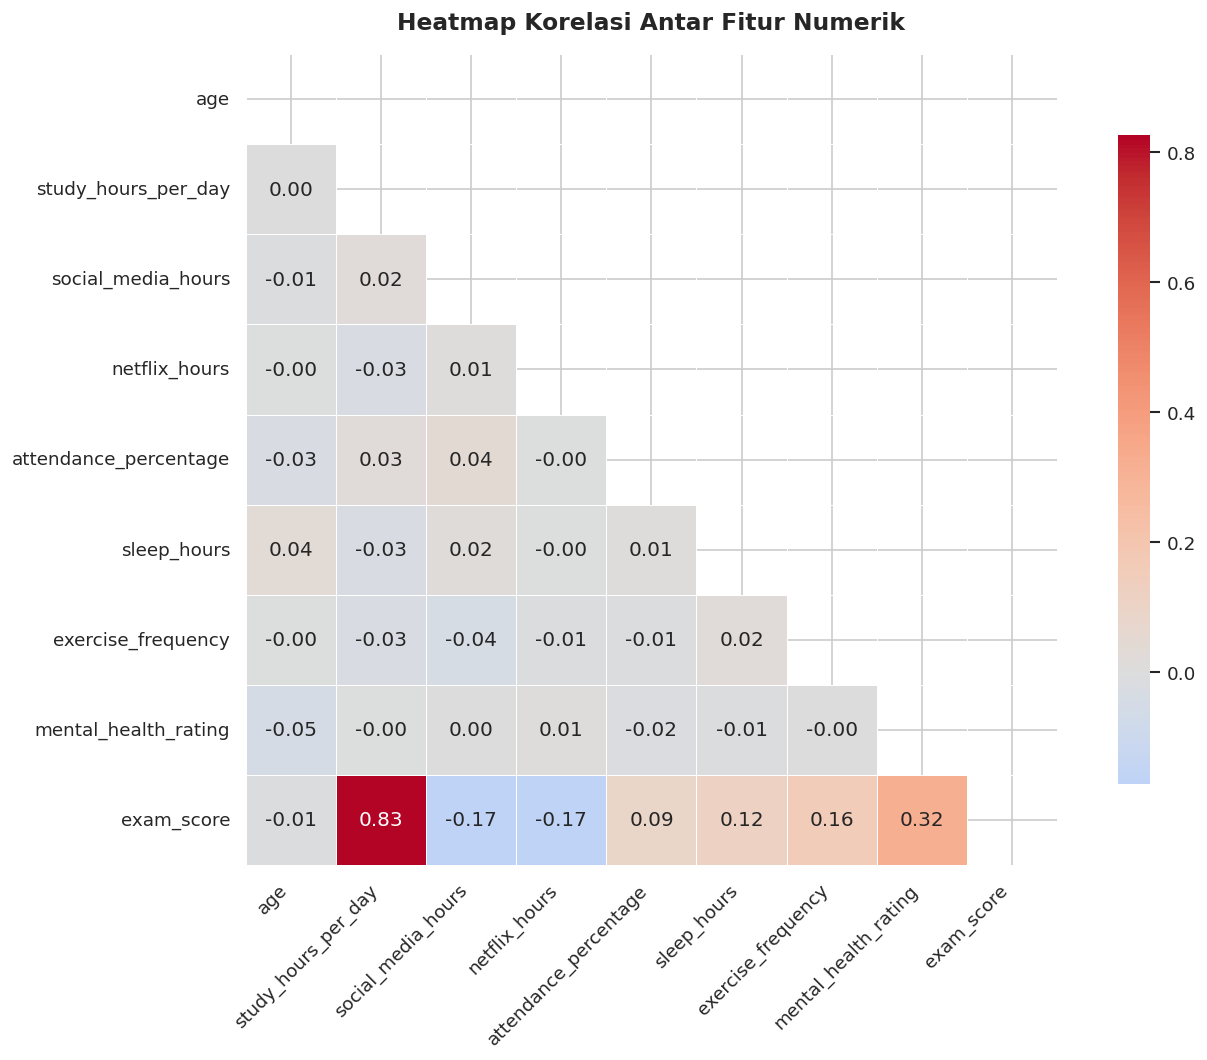

In [ ]:
# Heatmap korelasi fitur numerik
plt.figure(figsize=(12, 9))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

TOP 10 FITUR PALING BERKORELASI DENGAN EXAM SCORE:
study_hours_per_day      0.825419
mental_health_rating     0.321523
netflix_hours            0.171779
social_media_hours       0.166733
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                      0.008907


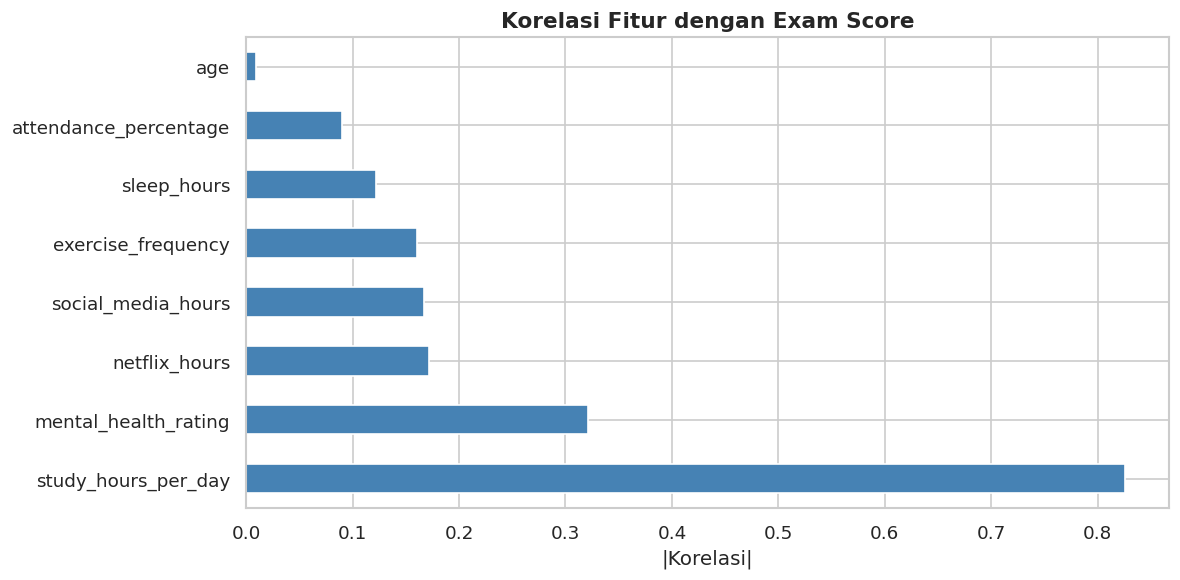

In [ ]:
# Top 10 fitur paling berkorelasi dengan exam_score
corr_target = df_raw[num_cols].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
print('TOP 10 FITUR PALING BERKORELASI DENGAN EXAM SCORE:')
print(corr_target.head(10).to_string())

plt.figure(figsize=(10, 5))
corr_target.head(10).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Korelasi Fitur dengan Exam Score', fontsize=13, fontweight='bold')
plt.xlabel('|Korelasi|')
plt.tight_layout()
plt.savefig('korelasi_target.png', bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

In [ ]:
df = df_raw.copy()

# --- 5.1 Handle Missing Values ---
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'  {col}: diisi dengan median')
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  {col}: diisi dengan modus')

print('✅ Missing values ditangani')

  parental_education_level: diisi dengan modus
✅ Missing values ditangani


In [ ]:
# --- 5.2 Encoding kolom kategorikal ---
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f'  {col}: {le.classes_}')

print('\n✅ Encoding selesai')

  student_id: ['S1000' 'S1001' 'S1002' 'S1003' 'S1004' 'S1005' 'S1006' 'S1007' 'S1008'
 'S1009' 'S1010' 'S1011' 'S1012' 'S1013' 'S1014' 'S1015' 'S1016' 'S1017'
 'S1018' 'S1019' 'S1020' 'S1021' 'S1022' 'S1023' 'S1024' 'S1025' 'S1026'
 'S1027' 'S1028' 'S1029' 'S1030' 'S1031' 'S1032' 'S1033' 'S1034' 'S1035'
 'S1036' 'S1037' 'S1038' 'S1039' 'S1040' 'S1041' 'S1042' 'S1043' 'S1044'
 'S1045' 'S1046' 'S1047' 'S1048' 'S1049' 'S1050' 'S1051' 'S1052' 'S1053'
 'S1054' 'S1055' 'S1056' 'S1057' 'S1058' 'S1059' 'S1060' 'S1061' 'S1062'
 'S1063' 'S1064' 'S1065' 'S1066' 'S1067' 'S1068' 'S1069' 'S1070' 'S1071'
 'S1072' 'S1073' 'S1074' 'S1075' 'S1076' 'S1077' 'S1078' 'S1079' 'S1080'
 'S1081' 'S1082' 'S1083' 'S1084' 'S1085' 'S1086' 'S1087' 'S1088' 'S1089'
 'S1090' 'S1091' 'S1092' 'S1093' 'S1094' 'S1095' 'S1096' 'S1097' 'S1098'
 'S1099' 'S1100' 'S1101' 'S1102' 'S1103' 'S1104' 'S1105' 'S1106' 'S1107'
 'S1108' 'S1109' 'S1110' 'S1111' 'S1112' 'S1113' 'S1114' 'S1115' 'S1116'
 'S1117' 'S1118' 'S1119' 'S1120' 'S11

Distribusi label performa:
performa
Medium    491
High      378
Low       131
Name: count, dtype: int64

Proporsi (%):
performa
Medium    49.1
High      37.8
Low       13.1
Name: count, dtype: float64


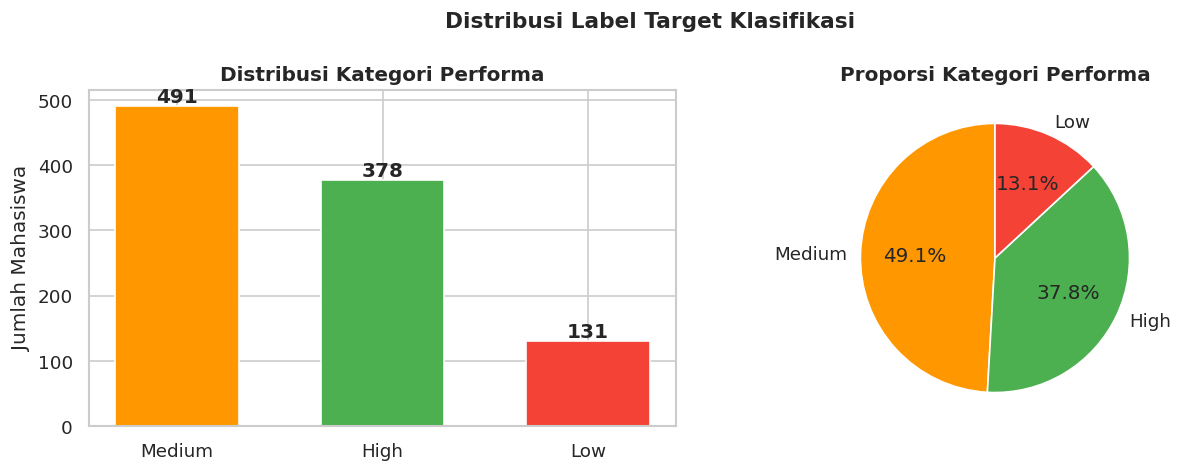

In [ ]:
# --- 5.3 Buat label performa akademik (target Classification) ---
# Kategorisasi exam_score: Low / Medium / High
def label_performa(score):
    if score < 50:
        return 'Low'
    elif score < 75:
        return 'Medium'
    else:
        return 'High'

df['performa'] = df[target_col].apply(label_performa)
print('Distribusi label performa:')
print(df['performa'].value_counts())
print(f'\nProporsi (%):')
print((df['performa'].value_counts() / len(df) * 100).round(2))

# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors_perf = {'Low': '#F44336', 'Medium': '#FF9800', 'High': '#4CAF50'}
vc = df['performa'].value_counts()

axes[0].bar(vc.index, vc.values,
            color=[colors_perf[k] for k in vc.index], edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Kategori Performa', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[colors_perf[k] for k in vc.index],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporsi Kategori Performa', fontsize=12, fontweight='bold')

plt.suptitle('Distribusi Label Target Klasifikasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_label.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 5.4 Pilih fitur untuk model ---
# Fitur untuk Classification (semua fitur numerik + encoded)
enc_cols = [c + '_enc' for c in cat_cols if c + '_enc' in df.columns]
feature_num = [c for c in num_cols if c != target_col]
ALL_FEATURES = feature_num + enc_cols

# Fitur utama 5 input untuk Streamlit (sesuaikan nama kolom)
STREAMLIT_FEATURES = [c for c in [
    'sleep_hours', 'study_hours_per_day', 'social_media_hours',
    'physical_activity_hours', 'attendance_percentage'
] if c in df.columns]

print('Semua fitur untuk model:', ALL_FEATURES)
print('\nFitur Streamlit:', STREAMLIT_FEATURES)

# Encode label performa
le_performa = LabelEncoder()
df['performa_enc'] = le_performa.fit_transform(df['performa'])
print('\nMapping label:', dict(zip(le_performa.classes_, le_performa.transform(le_performa.classes_))))

Semua fitur untuk model: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'student_id_enc', 'gender_enc', 'part_time_job_enc', 'diet_quality_enc', 'parental_education_level_enc', 'internet_quality_enc', 'extracurricular_participation_enc']

Fitur Streamlit: ['sleep_hours', 'study_hours_per_day', 'social_media_hours', 'attendance_percentage']

Mapping label: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [ ]:
# --- 5.5 Normalisasi / Standarisasi ---
X_all = df[ALL_FEATURES].values
y_all = df['performa_enc'].values

# StandardScaler untuk classification
scaler_clf = StandardScaler()
X_scaled_clf = scaler_clf.fit_transform(X_all)

# MinMaxScaler untuk clustering (lebih intuitif untuk Silhouette)
X_cluster_raw = df[STREAMLIT_FEATURES].values if STREAMLIT_FEATURES else X_all
scaler_cluster = MinMaxScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster_raw)

print(f'✅ Scaling selesai')
print(f'  X classification shape : {X_scaled_clf.shape}')
print(f'  X clustering shape     : {X_scaled_cluster.shape}')

✅ Scaling selesai
  X classification shape : (1000, 15)
  X clustering shape     : (1000, 4)


In [ ]:
# --- 5.6 Split data untuk Classification ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_clf, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'Training set : {X_train.shape[0]} data')
print(f'Testing set  : {X_test.shape[0]} data')
print(f'Rasio        : 80% / 20%')

Training set : 800 data
Testing set  : 200 data
Rasio        : 80% / 20%



## 🤖 5. Modeling — Classification
### 5.1 Perbandingan Beberapa Algoritma

In [ ]:
# Definisi kandidat model
models = {
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5)
}

results = {}
print('Melatih dan mengevaluasi model...')
print('-' * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    cv  = cross_val_score(model, X_scaled_clf, y_all, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'CV Accuracy': cv}
    print(f'{name:22s} | Acc: {acc:.4f} | F1: {f1:.4f} | CV: {cv:.4f}')

print('-' * 55)
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print('\n📊 Rangkuman Perbandingan Model:')
print(results_df.round(4))

Melatih dan mengevaluasi model...
-------------------------------------------------------
Decision Tree          | Acc: 0.7000 | F1: 0.6995 | CV: 0.6610
Random Forest          | Acc: 0.7300 | F1: 0.7177 | CV: 0.7870
Gradient Boosting      | Acc: 0.7450 | F1: 0.7418 | CV: 0.7570
K-Nearest Neighbors    | Acc: 0.6300 | F1: 0.6229 | CV: 0.6060
-------------------------------------------------------

📊 Rangkuman Perbandingan Model:
                     Accuracy  F1-Score  CV Accuracy
Gradient Boosting       0.745    0.7418        0.757
Random Forest           0.730    0.7177        0.787
Decision Tree           0.700    0.6995        0.661
K-Nearest Neighbors     0.630    0.6229        0.606


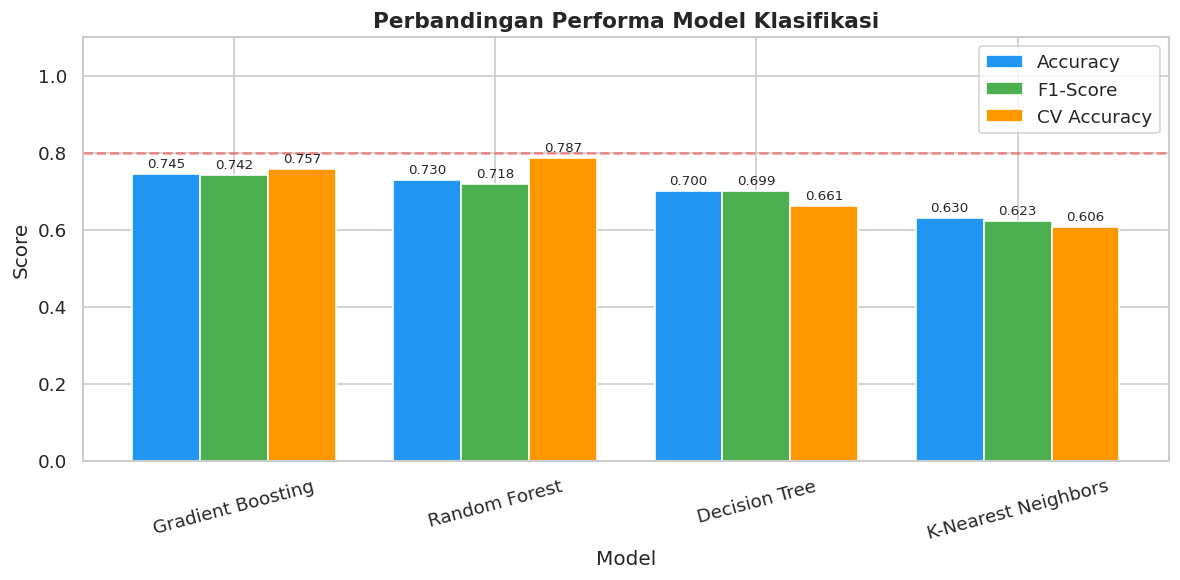

In [ ]:
# Visualisasi perbandingan performa model
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.26

bars1 = ax.bar(x - width, results_df['Accuracy'],   width, label='Accuracy',    color='#2196F3', edgecolor='white')
bars2 = ax.bar(x,         results_df['F1-Score'],   width, label='F1-Score',    color='#4CAF50', edgecolor='white')
bars3 = ax.bar(x + width, results_df['CV Accuracy'], width, label='CV Accuracy', color='#FF9800', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model Klasifikasi', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='Threshold 80%')

for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_model.png', bbox_inches='tight')
plt.show()

### 5.2 Tuning & Evaluasi Model Terbaik (Random Forest)

In [ ]:
# GridSearch untuk Random Forest
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [None, 5, 10, 15],
    'min_samples_split': [2, 5]
}

print('🔍 Grid Search sedang berjalan...')
gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs.fit(X_train, y_train)
print(f'✅ Parameter terbaik: {gs.best_params_}')
print(f'   CV Accuracy terbaik: {gs.best_score_:.4f}')

🔍 Grid Search sedang berjalan...
✅ Parameter terbaik: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   CV Accuracy terbaik: 0.7900


In [ ]:
# Evaluasi model terbaik
best_clf = gs.best_estimator_
y_pred_best = best_clf.predict(X_test)
label_names = le_performa.classes_

print('=' * 60)
print('EVALUASI MODEL TERBAIK (Random Forest + GridSearch)')
print('=' * 60)
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=label_names))

EVALUASI MODEL TERBAIK (Random Forest + GridSearch)
Accuracy : 0.7100
F1-Score : 0.6985

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.75      0.75        76
         Low       0.89      0.31      0.46        26
      Medium       0.68      0.79      0.73        98

    accuracy                           0.71       200
   macro avg       0.77      0.61      0.64       200
weighted avg       0.73      0.71      0.70       200



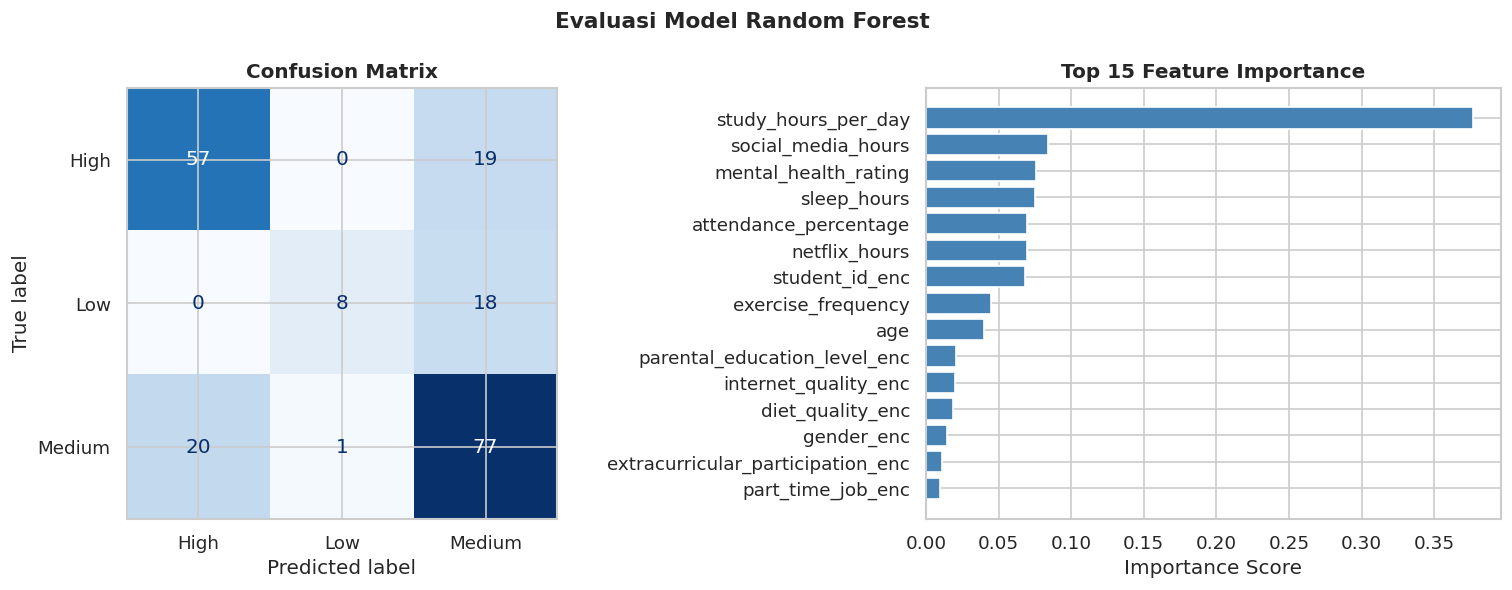

In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix angka
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Feature Importance
importances = best_clf.feature_importances_
fi_df = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': importances})\
           .sort_values('Importance', ascending=True).tail(15)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Evaluasi Model Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_classification.png', bbox_inches='tight')
plt.show()


## 6. Modeling — Clustering
### 6.1 Menentukan Jumlah Cluster Optimal

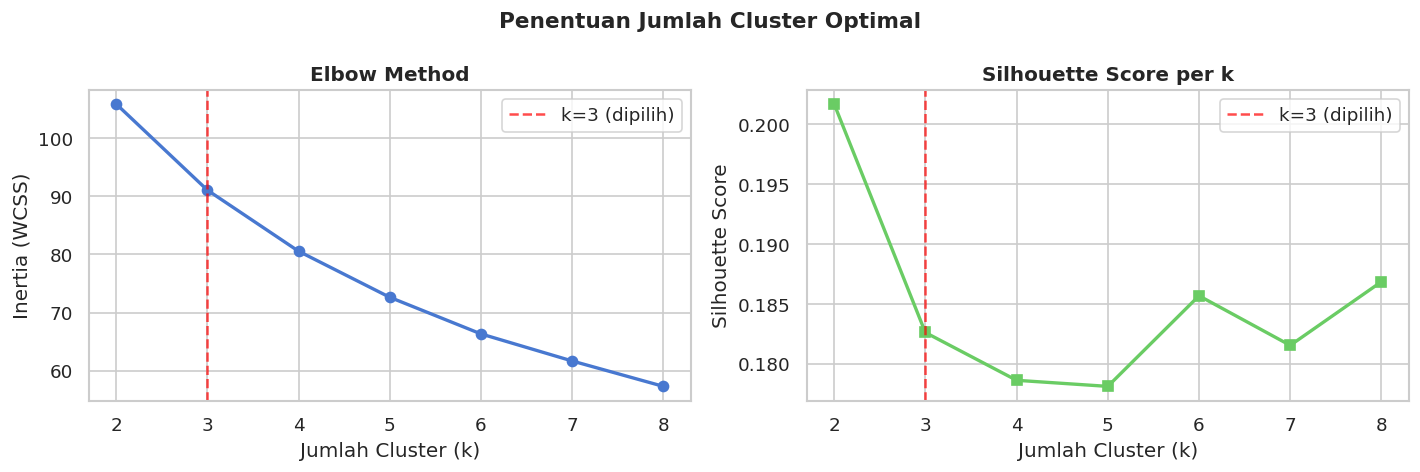

Silhouette Score per k:
  k=2: 0.2017
  k=3: 0.1826 ← dipilih
  k=4: 0.1786
  k=5: 0.1781
  k=6: 0.1857
  k=7: 0.1815
  k=8: 0.1868


In [ ]:
# Elbow Method
inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=6)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (dipilih)')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, 'gs-', linewidth=2, markersize=6)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (dipilih)')
axes[1].set_title('Silhouette Score per k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

print('Silhouette Score per k:')
for k, s in zip(k_range, sil_scores):
    marker = ' ← dipilih' if k == 3 else ''
    print(f'  k={k}: {s:.4f}{marker}')

### 6.2 K-Means Clustering (k=3)

In [ ]:
# Fit K-Means dengan k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_cluster)
df['cluster'] = cluster_labels

sil = silhouette_score(X_scaled_cluster, cluster_labels)
db  = davies_bouldin_score(X_scaled_cluster, cluster_labels)

print(f'✅ K-Means k=3 selesai')
print(f'   Silhouette Score    : {sil:.4f}  (semakin mendekati 1 = semakin baik)')
print(f'   Davies-Bouldin Score: {db:.4f}   (semakin kecil = semakin baik)')
print(f'\nJumlah data per cluster:')
print(df['cluster'].value_counts().sort_index())

✅ K-Means k=3 selesai
   Silhouette Score    : 0.1826  (semakin mendekati 1 = semakin baik)
   Davies-Bouldin Score: 1.6692   (semakin kecil = semakin baik)

Jumlah data per cluster:
cluster
0    341
1    303
2    356
Name: count, dtype: int64


In [ ]:
# Profil rata-rata setiap cluster
cluster_profile = df.groupby('cluster')[STREAMLIT_FEATURES + [target_col]].mean().round(2)
print('PROFIL RATA-RATA SETIAP CLUSTER:')
print(cluster_profile)

# Labeling otomatis cluster berdasarkan karakteristik
# Cari cluster dengan jam tidur tertinggi → Sehat
# Cluster dengan jam tidur terendah → Kurang Tidur
# Cluster tengah/exam_score rendah → Berisiko

sleep_col = 'sleep_hours' if 'sleep_hours' in STREAMLIT_FEATURES else STREAMLIT_FEATURES[0]
score_means = cluster_profile[target_col]

# Tentukan label berdasarkan exam_score rata-rata
sorted_clusters = score_means.sort_values(ascending=False).index.tolist()
CLUSTER_NAMES = {
    sorted_clusters[0]: 'Sehat',
    sorted_clusters[1]: 'Berisiko',
    sorted_clusters[2]: 'Kurang Tidur'
}

df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES)
print('\nMapping cluster:')
for k, v in CLUSTER_NAMES.items():
    print(f'  Cluster {k} → {v}')

PROFIL RATA-RATA SETIAP CLUSTER:
         sleep_hours  study_hours_per_day  social_media_hours  \
cluster                                                         
0               6.23                 3.77                2.40   
1               7.01                 2.13                2.47   
2               6.24                 4.55                2.64   

         attendance_percentage  exam_score  
cluster                                     
0                        74.31       70.11  
1                        86.68       57.72  
2                        91.38       79.23  

Mapping cluster:
  Cluster 2 → Sehat
  Cluster 0 → Berisiko
  Cluster 1 → Kurang Tidur


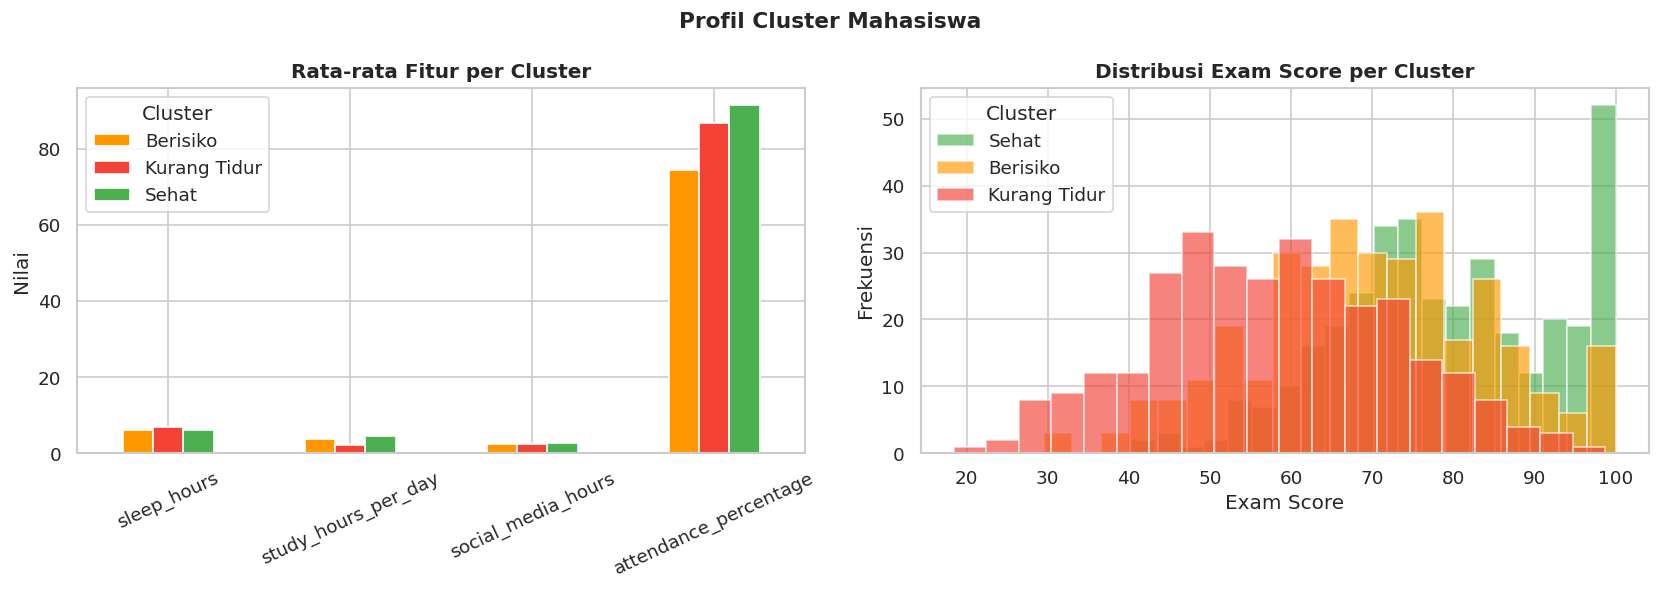

In [ ]:
# Visualisasi profil cluster (Radar / Bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_vis = df.groupby('cluster_name')[STREAMLIT_FEATURES].mean()
colors_clust = {'Sehat': '#4CAF50', 'Berisiko': '#FF9800', 'Kurang Tidur': '#F44336'}

cluster_vis.T.plot(kind='bar', ax=axes[0],
                   color=[colors_clust.get(c, 'gray') for c in cluster_vis.index],
                   edgecolor='white', rot=25)
axes[0].set_title('Rata-rata Fitur per Cluster', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nilai')
axes[0].legend(title='Cluster')

# Distribusi exam score per cluster
for cname in ['Sehat', 'Berisiko', 'Kurang Tidur']:
    sub = df[df['cluster_name'] == cname][target_col]
    if not sub.empty:
        axes[1].hist(sub, bins=20, alpha=0.65, label=cname,
                     color=colors_clust[cname], edgecolor='white')

axes[1].set_title('Distribusi Exam Score per Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(title='Cluster')

plt.suptitle('Profil Cluster Mahasiswa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('profil_cluster.png', bbox_inches='tight')
plt.show()

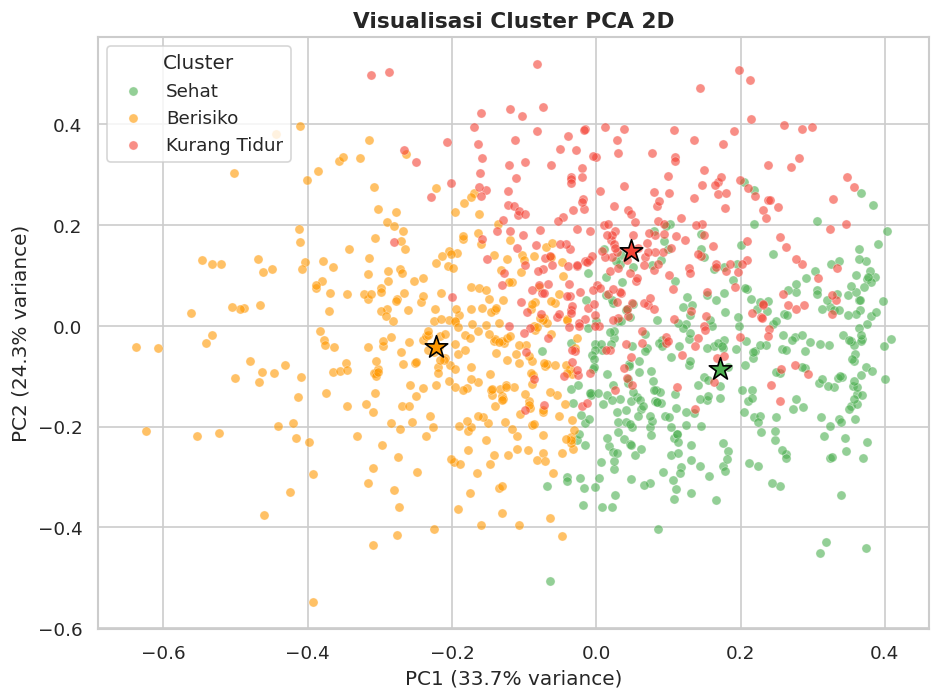

Total variance explained: 58.0%


In [ ]:
# Visualisasi PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_cluster)

plt.figure(figsize=(8, 6))
for cid, cname in CLUSTER_NAMES.items():
    mask = df['cluster'] == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_clust[cname], label=cname, alpha=0.6, s=30, edgecolors='white', linewidths=0.3)

# Plot centroids
centers_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centers_pca):
    cname = CLUSTER_NAMES[i]
    plt.scatter(cx, cy, c=colors_clust[cname], s=200, marker='*', edgecolors='black', linewidths=1, zorder=5)

plt.title('Visualisasi Cluster PCA 2D', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('cluster_pca.png', bbox_inches='tight')
plt.show()
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

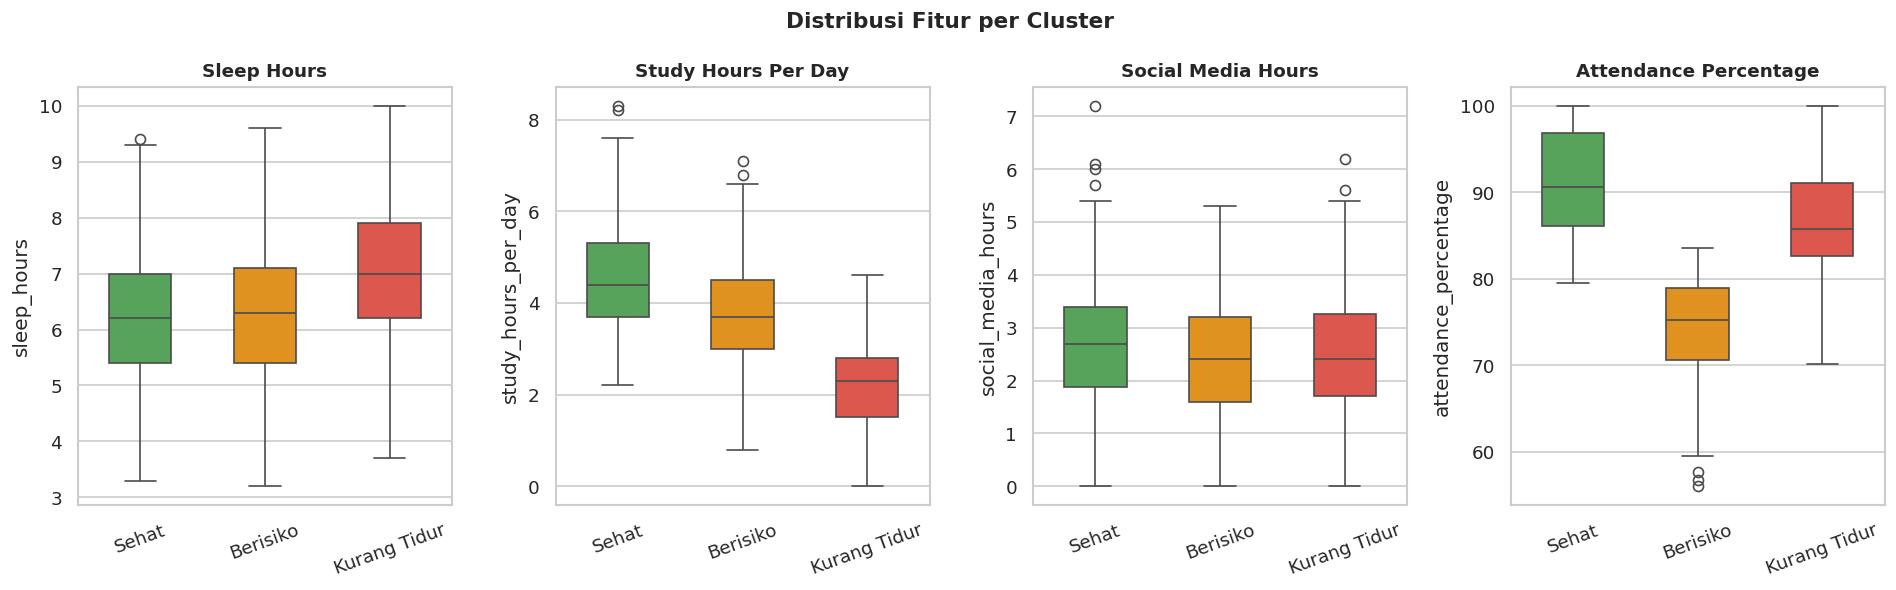

In [ ]:
# Boxplot per cluster untuk setiap fitur utama
n_feat = len(STREAMLIT_FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 5))
if n_feat == 1:
    axes = [axes]

order = ['Sehat', 'Berisiko', 'Kurang Tidur']
palette = {'Sehat': '#4CAF50', 'Berisiko': '#FF9800', 'Kurang Tidur': '#F44336'}

for ax, feat in zip(axes, STREAMLIT_FEATURES):
    sns.boxplot(data=df, x='cluster_name', y=feat, order=order,
                palette=palette, ax=ax, width=0.5)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

plt.suptitle('Distribusi Fitur per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_cluster.png', bbox_inches='tight')
plt.show()


## 7. Interpretasi Hasil

In [ ]:

print('RANGKUMAN HASIL ANALISIS')

print('\n📌 CLASSIFICATION (Random Forest):')
print(f'   Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'   F1-Score  : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'   Parameter : {gs.best_params_}')

print('\n📌 CLUSTERING (K-Means, k=3):')
print(f'   Silhouette Score    : {sil:.4f}')
print(f'   Davies-Bouldin Score: {db:.4f}')
print(f'   Cluster             : Sehat | Berisiko | Kurang Tidur')

print('\n📌 PROFIL CLUSTER:')
print(df.groupby('cluster_name')[[target_col] + STREAMLIT_FEATURES].mean().round(2).to_string())

print('\n📌 INTERPRETASI:')
for cname in ['Sehat', 'Berisiko', 'Kurang Tidur']:
    sub = df[df['cluster_name'] == cname]
    if not sub.empty:
        avg_score = sub[target_col].mean()
        n = len(sub)
        print(f'   {cname:14s}: {n} mahasiswa | Avg score = {avg_score:.2f}')


## 8. Simpan Model

In [ ]:
os.makedirs('model', exist_ok=True)

# Simpan semua artifact
joblib.dump(best_clf,      'model/model_clf.pkl')
joblib.dump(kmeans,        'model/model_cluster.pkl')
joblib.dump(scaler_clf,    'model/scaler_clf.pkl')
joblib.dump(scaler_cluster,'model/scaler_cluster.pkl')
joblib.dump(le_performa,   'model/le_performa.pkl')
joblib.dump(le_dict,       'model/le_dict.pkl')

# Simpan info cluster names
import json
with open('model/cluster_names.json', 'w') as f:
    json.dump({str(k): v for k, v in CLUSTER_NAMES.items()}, f)
with open('model/streamlit_features.json', 'w') as f:
    json.dump(STREAMLIT_FEATURES, f)
with open('model/all_features.json', 'w') as f:
    json.dump(ALL_FEATURES, f)

print('✅ Model berhasil disimpan ke folder model/')
for fname in sorted(os.listdir('model')):
    fpath = os.path.join('model', fname)
    size  = os.path.getsize(fpath)
    print(f'   {fname:30s} ({size:,} bytes)')

✅ Model berhasil disimpan ke folder model/
   all_features.json              (321 bytes)
   cluster_names.json             (52 bytes)
   le_dict.pkl                    (9,989 bytes)
   le_performa.pkl                (495 bytes)
   model_clf.pkl                  (5,719,809 bytes)
   model_cluster.pkl              (4,823 bytes)
   scaler_clf.pkl                 (959 bytes)
   scaler_cluster.pkl             (823 bytes)
   streamlit_features.json        (85 bytes)


In [ ]:
# ✅ QUICK TEST: Prediksi dengan input contoh (simulasi Streamlit)
import json

print('TEST PREDIKSI (simulasi input Streamlit)\n')

# Input contoh: tidur 7 jam, belajar 4 jam, sosmed 2 jam, olahraga 1 jam, kehadiran 85%
# Urutan harus sesuai STREAMLIT_FEATURES
sample_input = {f: 0 for f in STREAMLIT_FEATURES}
sample_input.update({
    'sleep_hours':              7.0,
    'study_hours_per_day':      4.0,
    'social_media_hours':       2.0,
    'physical_activity_hours':  1.0,
    'attendance_percentage':   85.0
})

sample_arr_cluster = np.array([[sample_input[f] for f in STREAMLIT_FEATURES]])
sample_scaled_cluster = scaler_cluster.transform(sample_arr_cluster)

# Cluster prediction
clust_pred = kmeans.predict(sample_scaled_cluster)[0]
clust_name = CLUSTER_NAMES.get(clust_pred, f'Cluster {clust_pred}')

# Classification — perlu semua fitur, isi nilai tengah untuk sisanya
sample_all = np.zeros((1, len(ALL_FEATURES)))
for i, feat in enumerate(ALL_FEATURES):
    if feat in sample_input:
        sample_all[0, i] = sample_input[feat]
    else:
        sample_all[0, i] = df[feat].median() if feat in df.columns else 0

sample_scaled_clf = scaler_clf.transform(sample_all)
clf_pred = best_clf.predict(sample_scaled_clf)[0]
clf_proba = best_clf.predict_proba(sample_scaled_clf)[0]
clf_name = le_performa.inverse_transform([clf_pred])[0]

print('Input mahasiswa:')
for k, v in sample_input.items():
    if v != 0:
        print(f'  {k}: {v}')
print(f'\n🔵 Cluster          : {clust_name} (Cluster {clust_pred})')
print(f'🟢 Performa Akademik: {clf_name}')
print(f'   Probabilitas    : { {le_performa.classes_[i]: f"{p:.2%}" for i, p in enumerate(clf_proba)} }')

TEST PREDIKSI (simulasi input Streamlit)

Input mahasiswa:
  sleep_hours: 7.0
  study_hours_per_day: 4.0
  social_media_hours: 2.0
  attendance_percentage: 85.0
  physical_activity_hours: 1.0

🔵 Cluster          : Sehat (Cluster 2)
🟢 Performa Akademik: Medium
   Probabilitas    : {'High': '45.50%', 'Low': '1.50%', 'Medium': '53.00%'}



## 9 Zip Semua Output
Download model dan gambar untuk digunakan di Streamlit.

In [ ]:
import shutil

# Kumpulkan semua gambar output
os.makedirs('output_gambar', exist_ok=True)
for f in [
    'dist_exam_score.png', 'dist_fitur_utama.png', 'heatmap_korelasi.png',
    'korelasi_target.png', 'distribusi_label.png', 'perbandingan_model.png',
    'eval_classification.png', 'elbow_silhouette.png', 'profil_cluster.png',
    'cluster_pca.png', 'boxplot_cluster.png'
]:
    if os.path.exists(f):
        shutil.copy(f, 'output_gambar/')

# Zip model
shutil.make_archive('model_export', 'zip', 'model')
shutil.make_archive('gambar_export', 'zip', 'output_gambar')

print('✅ model_export.zip  → upload ke folder /model Streamlit')
print('✅ gambar_export.zip → opsional untuk laporan')

# Download otomatis di Colab
try:
    from google.colab import files
    files.download('model_export.zip')
    print('\n📥 Download dimulai...')
except ImportError:
    print('\n⚠️  Bukan environment Colab, download manual dari panel kiri.')

✅ model_export.zip  → upload ke folder /model Streamlit
✅ gambar_export.zip → opsional untuk laporan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download dimulai...
